# Experimenting with Tool calling and the ReAct Pattern

In [2]:
from dotenv import load_dotenv
load_dotenv("../../.env")


from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

from IPython.display import Image, display

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

In [5]:
def dummy_tools(a: str, b: str ) -> str: 
    """Concatenate two strings.

    Arg:
    : a : string 1 to concat
    : b : string 2 to concat

    Returns:
        Concatenated string
    """

    return f"{a} {b}"

In [6]:
llm = ChatOpenAI(
    model="gpt-5.4-mini",
    reasoning_effort="none",
    use_responses_api=True
)

llm_with_tool = llm.bind_tools(
    [dummy_tools],
    tool_choice="auto"
)

In [7]:
response = llm_with_tool.invoke("Use dummy tool to concat two short strings")

In [8]:
response

AIMessage(content=[{'arguments': '{"a":"Hello, ","b":"world!"}', 'call_id': 'call_24ND2s7RJM2THLgf0sHrBVG4', 'name': 'dummy_tools', 'type': 'function_call', 'id': 'fc_0d94739131934526006a50031f429c819eb5ac8b94e3dbd077', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0d94739131934526006a50031e94f8819ea9d44e24e5bff1d6', 'created_at': 1783628574.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_0d94739131934526006a50031e94f8819ea9d44e24e5bff1d6', tool_calls=[{'name': 'dummy_tools', 'args': {'a': 'Hello, ', 'b': 'world!'}, 'id': 'call_24ND2s7RJM2THLgf0sHrBVG4', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 74, 'output_tokens': 25, 'total_tokens': 99, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 0}})

In [9]:
response.usage_metadata

{'input_tokens': 74,
 'output_tokens': 25,
 'total_tokens': 99,
 'input_token_details': {'cache_read': 0},
 'output_token_details': {'reasoning': 0}}

In [10]:
response.tool_calls

[{'name': 'dummy_tools',
  'args': {'a': 'Hello, ', 'b': 'world!'},
  'id': 'call_24ND2s7RJM2THLgf0sHrBVG4',
  'type': 'tool_call'}]

In [12]:
response.content

[{'arguments': '{"a":"Hello, ","b":"world!"}',
  'call_id': 'call_24ND2s7RJM2THLgf0sHrBVG4',
  'name': 'dummy_tools',
  'type': 'function_call',
  'id': 'fc_0d94739131934526006a50031f429c819eb5ac8b94e3dbd077',
  'status': 'completed'}]

### Example Agent Graph

In [44]:
@tool
def append_vibes(query: str, vibe: str) -> str:
    """Concatenate the query with the vibe string.

    Arg:
    : query : string 1 is the input query
    : vibe : string 2 is the vibe

    Returns:
        Concatenated string with query and vibe appended
    """
    return f"{query} {vibe}"

In [45]:
from typing import Any, List, Annotated, Literal
from operator import add

class State(BaseModel):
    query: str
    messages: Annotated[List[Any], add] = [] 
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False

In [54]:
from jinja2 import Template
from langchain_core.messages import SystemMessage

def agent_node(state: State) -> dict:
    jinja_prompt_template = """You are an assistent that helps the user to generate vibes.
    Check available tools and use tools to add vibes to the query.

    ## User Query
    {{ query }}
    """
    template = Template(jinja_prompt_template)

    prompt = template.render(
        query=state.query
    )

    llm_client = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort="none",
        use_responses_api=True
    )

    llm_client_with_tools = llm_client.bind_tools(
        [append_vibes],
        tool_choice="auto"
    )

    response = llm_client_with_tools.invoke([
        SystemMessage(content=prompt),
    ])

    return {
        "messages": [response]
    }


In [55]:
def tool_router(state: State) -> str:
    if len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [ ]:
from langgraph.prebuilt import ToolNode

workflow = StateGraph(State)

#tools
tools = [append_vibes]
tool_node = ToolNode(tools)

# nodes
workflow.add_node("agent_node", agent_node)
workflow.add_node("tool_node", tool_node)

# edges
workflow.add_edge(START, "agent_node")

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END,
    }
)

workflow.add_edge("tool_node", END)

graph = workflow.compile()


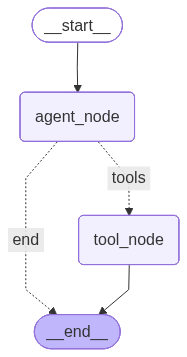

In [ ]:
display(Image(
    graph.get_graph().draw_mermaid_png()
))

In [58]:
initial_state = {
    "query": "Give me some vibes"
}

In [ ]:
result = graph.invoke(initial_state)

In [60]:
result

{'query': 'Give me some vibes',
 'messages': [AIMessage(content=[{'arguments': '{"query":"Give me some vibes","vibe":"Chill, upbeat, and a little playful"}', 'call_id': 'call_afKMT4n2T8xpjxi5FarQAzPd', 'name': 'append_vibes', 'type': 'function_call', 'id': 'fc_0e87931f6bb237e6006a5216bb619481a3a3f27dfc0ef36979', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0e87931f6bb237e6006a5216bafed881a38ffa64652b3057e6', 'created_at': 1783764667.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_0e87931f6bb237e6006a5216bafed881a38ffa64652b3057e6', tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibes', 'vibe': 'Chill, upbeat, and a little playful'}, 'id': 'call_afKMT4n2T8xpjxi5FarQAzPd', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 126, 'output_tokens': 35, 'to

## Agent Graph with loop back from tools (ReAct Agent)

In [70]:
class State(BaseModel):
    query: str
    messages: Annotated[List[Any], add] = [] 
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False

class FinalResponse(BaseModel):
    response: str

In [75]:
def agent_node(state: State) -> dict:
    jinja_prompt_template = """You are an assistent that helps the user to generate vibes.
    Check available tools and use tools to add vibes to the query.

    ## User Query
    {{ query }}
    """
    template = Template(jinja_prompt_template)

    prompt = template.render(
        query=state.query
    )

    llm_client = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort="none",
        use_responses_api=True
    )

    llm_client_with_tools = llm_client.bind_tools(
        [append_vibes, FinalResponse],
        tool_choice="auto"
    )

    response = llm_client_with_tools.invoke([
        SystemMessage(content=prompt),
        *state.messages
    ])

    final_answer = False
    answer = ""
    if len(response.tool_calls) > 0:
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalResponse":
                final_answer = True
                answer = tool_call.get("args").get("answer")
                break

    return {
        "messages": [response],
        "final_answer": final_answer,
        "answer": answer,
        "iteration": state.iteration + 1
    }


In [76]:
def tool_router(state: State) -> str:
    if state.final_answer:
        return "end"
    elif state.iteration >= 3:
        return "end"
    elif len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [77]:
from langgraph.prebuilt import ToolNode

react_workflow = StateGraph(State)

#tools
tools = [append_vibes]
tool_node = ToolNode(tools)

# nodes
react_workflow.add_node("agent_node", agent_node)
react_workflow.add_node("tool_node", tool_node)

# edges
react_workflow.add_edge(START, "agent_node")

react_workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END,
    }
)

react_workflow.add_edge("tool_node", "agent_node")

react_graph = react_workflow.compile()


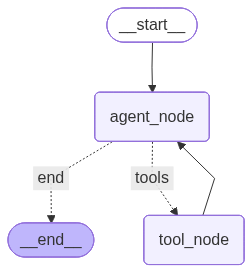

In [78]:
display(Image(
    react_graph.get_graph().draw_mermaid_png()
))

In [79]:
initial_state = {"query": "How are you today?"}

In [80]:
result = react_graph.invoke(initial_state)

In [81]:
result

{'query': 'How are you today?',
 'messages': [AIMessage(content=[{'arguments': '{"query":"How are you today?","vibe":"friendly, warm, upbeat"}', 'call_id': 'call_sLCYQpSh5hNc6wN7KB9bWeSF', 'name': 'append_vibes', 'type': 'function_call', 'id': 'fc_008a37aab63c3047006a521c0356dc819f9be238f804c32d0d', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_008a37aab63c3047006a521c02a8f8819fad9f8b8c72a5697c', 'created_at': 1783766018.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_008a37aab63c3047006a521c02a8f8819fad9f8b8c72a5697c', tool_calls=[{'name': 'append_vibes', 'args': {'query': 'How are you today?', 'vibe': 'friendly, warm, upbeat'}, 'id': 'call_sLCYQpSh5hNc6wN7KB9bWeSF', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 140, 'output_tokens': 32, 'total_tokens': 172, 'input_t